# Set up your learning workspace

Runnable locally on CPU or on a Cloud TPU VM.

- Open a terminal in the folder containing your experiment.
- Create a project-specific Python environment and check which interpreter you are using.
- Install the course packages and run a saved Python file.
- Recognize a successful result, save the output, and resume in a new terminal.

Let’s get your first JAX experiment running. You do not need to know Git or terminal commands yet: we will show where to type each command and how to check the result. You will need a computer, an internet connection for the downloads, and permission to install Python. By the end, you’ll have one experiment and a record of what it produced. A laptop CPU is enough.

## The idea

Your first goal is a small, repeatable result: save a Python file, run it with the intended Python environment, and explain its output. A terminal accepts commands; Python executes the program; JAX is a package that Python imports. Keeping those three roles separate makes setup errors much easier to locate.

## Follow a file from saving to running

Imagine that your editor shows first_experiment.py, but the terminal says the file does not exist. The program has not reached JAX yet. First save the file, check its full filename, and compare its folder with the terminal's working folder. A file visible in an editor can still be unsaved or stored elsewhere.

Now suppose Python finds the file but cannot import JAX. That is a different boundary: the selected interpreter cannot find the package. Check the interpreter path and its environment before installing anything again. On Windows, the commands below select the environment's Python directly; shell activation is not required.

Once the calculation runs, retain the command and printed result together. Tomorrow, the command tells you how to reproduce the result; a screenshot of the number alone cannot identify the file or environment that produced it.

$$
\text{shape}(X) = (B, D), \qquad \text{dtype}(X) \in \{\text{float32}, \text{int32}\}
$$

### Where the first result comes from

**Predict:** The notebook imports JAX, but the terminal script does not. What should you compare first?

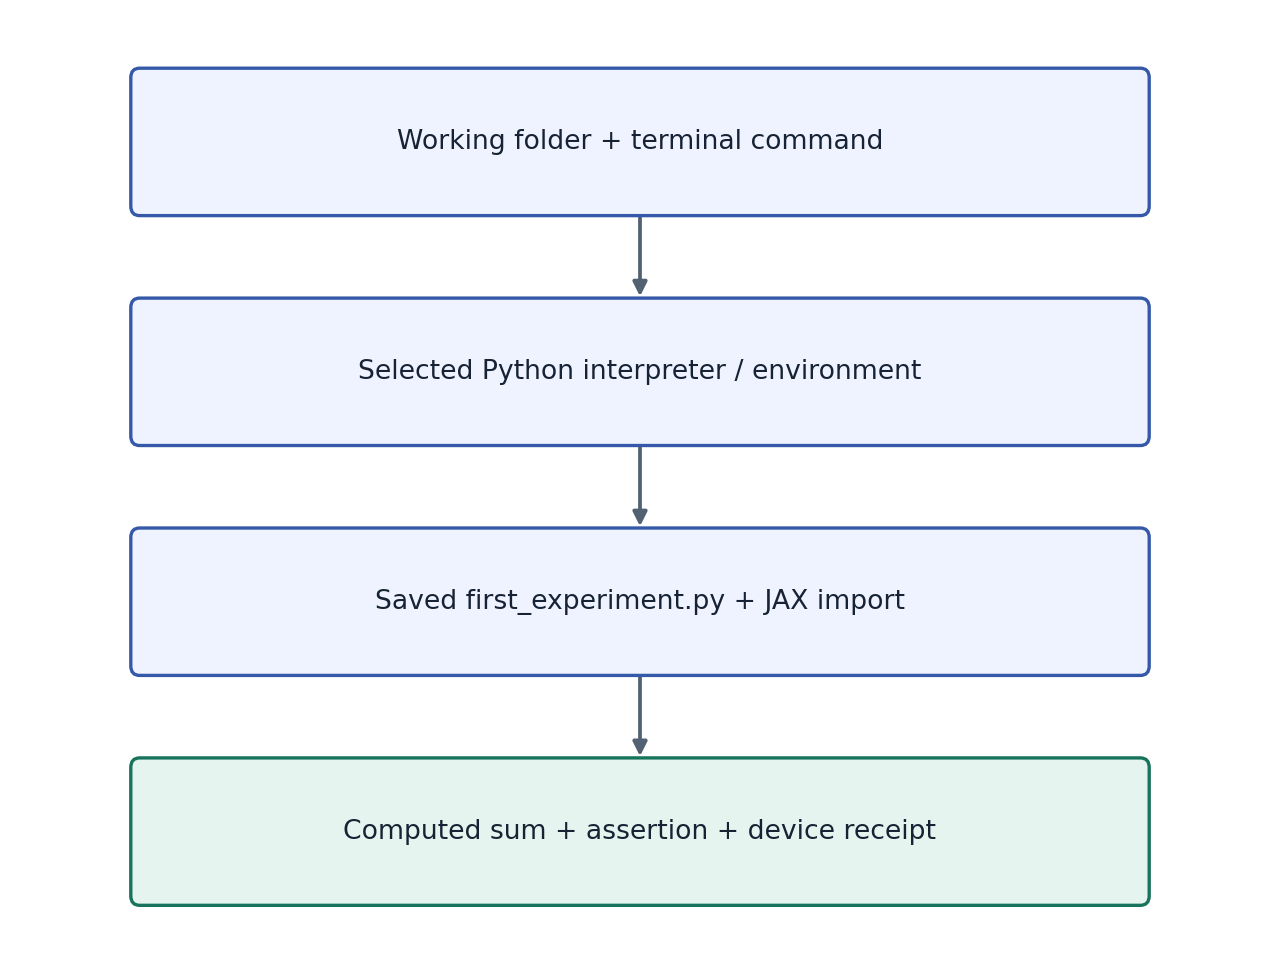

*Architecture and dataflow mechanism diagram.*

Read downward: a command runs from a working folder, selects an interpreter, opens the file and imports its packages before computing. Arrows are dependencies, not measured time. A file-path failure happens before JAX arithmetic; an import failure points to the selected environment.

### Pause and reason

The notebook imports JAX, but the terminal script does not. What should you compare first?

<details><summary>Compare your reasoning</summary>

Compare the Python executables used by the notebook kernel and terminal. They can belong to different environments. Install into, or select, the intended environment only after identifying that difference.

</details>

## 1. Download and unpack your workspace

Use the “Download the beginner workspace” button above. Open your Downloads folder and unzip jax-start-here.zip. On Windows, right-click it and choose Extract All; on macOS, double-click it. Open the extracted jax-start-here folder. Do not work inside the ZIP preview.

You should see first_experiment.py, requirements-cpu.txt, and START-HERE.md. first_experiment.py is the program you will run. requirements-cpu.txt lists the package versions to install. START-HERE.md is a copy of these instructions. Keep your own files alongside them, outside .venv. You do not need to clone the repository for this lesson.

## 2. Check that Python is installed

Open a terminal. On macOS, press Command–Space, type Terminal, and press Return. On Windows, open Start, type PowerShell, and open it. On Linux, open your desktop’s Terminal application.

Choose the command for your operating system below. Type or paste one line, then press Enter. Do not type a prompt symbol such as $ or PS>. If you see >>>, you are already inside the Python interpreter; type `exit()` and press Enter to return to the terminal before using these commands.

The course CPU examples were checked with Python 3.14.3. These commands select Python $3.14$. If you get “command not found” or “not recognized,” Python $3.14$ is not available through that command yet. Open the official Python downloads link in the references, select a Python $3.14$ installer for macOS or Windows, and follow the installer. On Windows, the launcher/install manager supplies py; on macOS, the Python installer supplies python3.14. Close and reopen the terminal after installing, then retry the version check. Linux installation depends on the distribution: use its Python $3.14$ installation instructions and return here once the version check works. Do not continue by substituting an old system Python without checking compatibility.

**macOS / Linux — terminal**

```sh
# Run macos / linux — terminal using the course Python environment
python3.14 --version
```

**Expected:** A line beginning Python 3.14. The last patch number may differ from the tested 3.14.3.

**Windows — PowerShell**

```powershell
# Windows — PowerShell
py -3.14 --version
```

**Expected:** A line beginning Python 3.14. If py exists but cannot find 3.14, install that Python version first.

## 3. Put the terminal in the right folder

The program and requirements file are in the extracted workspace. A command using a filename looks for it relative to the terminal’s current folder. We need the terminal to be in jax-start-here.

macOS: type cd followed by a space, drag the extracted jax-start-here folder from Finder into the terminal, then press Enter. Dragging inserts its actual path, including spaces correctly. Linux: use cd with the actual folder path in quotes; your file manager may offer “Open in Terminal.” Windows: open the extracted folder in File Explorer, click its address bar, type powershell, and press Enter. That opens PowerShell in this folder.

Run the appropriate check below. If requirements-cpu.txt is missing, move into the extracted folder containing that file before continuing. “Repository root” in later lessons means the top folder of the full course checkout; this beginner workspace is enough for the current experiment.

**macOS / Linux — check folder and files**

```sh
# macOS / Linux — check folder and files
pwd
ls
```

**Expected:** The path ends with your extracted workspace folder, and the file list includes first_experiment.py and requirements-cpu.txt.

**Windows — check folder and files**

```powershell
# Windows — check folder and files
Get-Location
Get-ChildItem
```

**Expected:** The displayed folder contains first_experiment.py and requirements-cpu.txt.

## 4. Create the environment and install the packages

Run the lines for your operating system in order, staying in the workspace folder. The venv command creates .venv using the Python version you just selected. It often finishes without printing anything. That is normal; wait until the terminal is ready for another command. If you already have a .venv from another Python version in this folder, use a fresh extracted workspace for this walkthrough.

On macOS/Linux, source loads the activation script into this terminal. You may see (.venv) at the start of the prompt. The important check is sys.executable: it should point inside this workspace’s .venv/bin. On Windows we use .venv\Scripts\python.exe explicitly, so no activation script or execution-policy change is needed.

The pip command is the package installer. -$r$ means “read the package list from this file.” It downloads and installs packages into the selected environment. Let it finish. Download messages are normal; a traceback or an ERROR means the step did not succeed. The final import check below is more useful than guessing from the download log. The pins describe the tested CPU course setup; accelerator installation is a later lesson.

**macOS / Linux — run one line at a time**

```sh
# Run macos / linux — run one line at a time using the course Python environment
python3.14 -m venv .venv
source .venv/bin/activate
python -c "import sys; print(sys.executable)"
python -m pip install -r requirements-cpu.txt
python -c "import jax, numpy, optax; print(jax.__version__, numpy.__version__, optax.__version__)"
```

**Expected:** The interpreter path includes .venv/bin/python. The final line is 0.9.2 2.4.4 0.2.8.

**Windows — run one line at a time**

```powershell
# Windows — run one line at a time
py -3.14 -m venv .venv
.\.venv\Scripts\python.exe -c "import sys; print(sys.executable)"
.\.venv\Scripts\python.exe -m pip install -r requirements-cpu.txt
.\.venv\Scripts\python.exe -c "import jax, numpy, optax; print(jax.__version__, numpy.__version__, optax.__version__)"
```

**Expected:** The interpreter path includes .venv\Scripts\python.exe. The final line is 0.9.2 2.4.4 0.2.8. These PowerShell instructions have not been executed on Windows in this project.

## 5. Run your first saved program

Open first_experiment.py in a text/code editor if you want to see its contents. The same Python program is shown below in “Run the example.” Python code belongs in that file; the commands below belong in the terminal. The downloaded file is already saved, so you can run it without copying any code.

Run the command for your operating system. The program prints the Python and package versions, the backend, the devices, and a sum. The starter explicitly selects CPU before importing JAX, so the expected backend here is cpu. The device description can vary; the final result should be Sum: $6.0$. The program constructs the numbers $0$, $1$, $2$, $3$; adding them gives $6$. This known result checks that we ran a numerical computation, not only installed a package.

If you see a traceback, read the final line and compare it with the troubleshooting section. Do not count a failed command as a completed experiment.

**macOS / Linux — activated terminal**

```sh
# Run macos / linux — activated terminal using the course Python environment
python first_experiment.py
```

**Expected:** Python: 3.14.x
JAX: 0.9.2
NumPy: 2.4.4
Backend: cpu
Devices: a CPU device description
Sum: 6.0

**Windows — PowerShell**

```powershell
# Run windows — powershell using the course Python environment
.\.venv\Scripts\python.exe first_experiment.py
```

**Expected:** The same version/backend/result lines. CPU device wording may differ.

## 6. Make one change and save your result

In the editor, find `arange(4, ...)` in first_experiment.py and change $4$ to $6$. The array now contains $0$ through $5$. Predict their sum before running. Also change the final assert from `== 6.0` to `== 15.0`, because that assertion is the program’s expected-result check. Save the file with its .py extension; a filename such as first_experiment.py.txt will not match the run command.

Run it again using the Step $5$ command. The final line should be Sum: $15.0$. If it still says $6.0$, check that you saved the file and that the terminal is in the same workspace folder you edited.

After that successful run, the commands below run it once more and save its printed output to my-first-run.txt. Open that text file and check that the versions, CPU information, and sum are present. Add a note in your editor explaining the one change and your prediction. The > symbol saves output to a file and replaces its previous contents; choose another filename when you want to keep multiple runs.

**macOS / Linux — save output**

```sh
# Run macos / linux — save output using the course Python environment
python first_experiment.py > my-first-run.txt
```

**Expected:** my-first-run.txt appears in the workspace and ends with Sum: 15.0 after your saved edit.

**Windows — save output**

```powershell
# Run windows — save output using the course Python environment
.\.venv\Scripts\python.exe first_experiment.py > my-first-run.txt
```

**Expected:** my-first-run.txt contains the program output after your saved edit.

## 7. Resume when you open a new terminal

The .venv folder stays on disk when you close the terminal. On macOS/Linux, activation only applied to the terminal you used; a new terminal needs it again. Move into the workspace folder using Step $3$, then use the commands below. You do not need to reinstall the packages on every session.

On Windows, move into the workspace and use the environment’s full Python path again. To leave an activated macOS/Linux environment, type deactivate. That changes the terminal’s command selection; it does not delete your code or installed packages.

**macOS / Linux — new terminal, same folder**

```sh
# macOS / Linux — new terminal, same folder
source .venv/bin/activate
python first_experiment.py
```

**Expected:** The same saved program runs using the existing environment.

**Windows — new PowerShell, same folder**

```powershell
# Run windows — new powershell, same folder using the course Python environment
.\.venv\Scripts\python.exe first_experiment.py
```

**Expected:** The explicit environment interpreter runs the saved program without activation.

## When a step fails: match the symptom

“No such file” / “Cannot find path” for requirements-cpu.txt: check Step $3$. The file must be in the current folder. Do not create an empty replacement file.

“No module named jax”: first check which Python is running. Repeat the interpreter-path check in Step $4$, then install using that exact environment interpreter. A different terminal or editor may be selecting a different environment.

“No module named venv” or a message that ensurepip is unavailable: your Python distribution is missing its environment component. On Linux, use the distribution’s matching Python/venv package instructions; package names vary. This needs fixing before the environment can be created.

“No matching distribution found” or a failed jaxlib wheel download: record the Python version, operating system, CPU architecture, and full error. Check the JAX installation support table linked below. Do not remove the version pins or switch to TPU packages as a blind workaround. CPU platform support is not identical across operating systems; this repository’s Windows walkthrough is documented but not execution-validated.

A SyntaxError after pasting a terminal command: check whether you pasted it into a Python file or at the >>> prompt. Terminal commands and Python statements have different places to run.

Sum: $15.0$ followed by AssertionError: you changed the array length but left the old expected sum in the assertion. Update the expectation after deriving the new result; do not delete the check merely to hide the failure.

## Step 1: Set up imports and input tensors

Import the required JAX modules and define the initial inputs for set up your learning workspace.

In [1]:
import os
# Choose CPU before importing JAX for this first experiment.
os.environ["JAX_PLATFORMS"] = "cpu"

Establishing explicit input shapes and dtypes first makes the downstream transformation contract deterministic.

## Step 2: Apply the core JAX transformation

Write the core computation and transformation step over the initialized inputs.

In [2]:
import platform
import jax

This stage executes the primary numerical transformation and binds the intermediate outputs.

## Step 3: Verify shapes and numerical invariants

Check that the resulting arrays satisfy the expected shape, dtype, and numerical tolerances.

In [3]:
import numpy as np
# Print the observed values to compare against the expected result.
# Print diagnostic summary of the computed outputs.
# Print diagnostic summary of the computed outputs.
# Print diagnostic summary of the computed outputs.
# Print diagnostic summary of the computed outputs.
# Run `jax.numpy.arange` to compute `x`.
x = jax.numpy.arange(4, dtype=jax.numpy.float32)
# Print the observed values to compare against the expected result.
# Assert invariant `float(x.sum()) == 6.0` holds
assert float(x.sum()) == 6.0

These assertions lock in the exact numerical contract before you run the full experiment and variations.

## Run the example

In [4]:
# Set up your learning workspace: Your first goal is a small, repeatable result: save a Python...
# Import os for this computation.
import os
# Choose CPU before importing JAX for this first experiment.
os.environ["JAX_PLATFORMS"] = "cpu"
# Import required JAX, NumPy, and standard-library modules.
import platform
import jax
import numpy as np
# Print the observed values to compare against the expected result.
print("Python:", platform.python_version())
# Print diagnostic summary of the computed outputs.
print("JAX:", jax.__version__)
# Print diagnostic summary of the computed outputs.
print("NumPy:", np.__version__)
# Print diagnostic summary of the computed outputs.
print("Backend:", jax.default_backend())
# Print diagnostic summary of the computed outputs.
print("Devices:", jax.devices())
# Run `jax.numpy.arange` to compute `x`.
x = jax.numpy.arange(4, dtype=jax.numpy.float32)
# Print the observed values to compare against the expected result.
print("Sum:", float(x.sum()))
# Assert invariant `float(x.sum()) == 6.0` holds
assert float(x.sum()) == 6.0

Python: 3.14.3
JAX: 0.9.2
NumPy: 2.4.4
Backend: cpu
Devices: [CpuDevice(id=0)]
Sum: 6.0


Expected: The package versions match the pins, Backend is cpu, and the last line is Sum: $6.0$. The exact Python patch and CPU device text depend on your installation.

## Workspace array verification across input elements

Predict: Before running, predict the element values and squared values of the 1D JAX array `x`.

CPU computation; rerun to recompute the data.

Run the cells below to produce the figure, then follow the walkthrough beneath it.

In [5]:
# Plot the 1D verification array `x` and its elementwise square `x ** 2`:
sq_vals = x ** 2
visual_data = {'kind': 'bar', 'x': list(range(len(x))), 'labels': [f'x[{i}]' for i in range(len(x))], 'xlabel': 'element index', 'ylabel': 'array value', 'series': [{'label': 'x', 'y': [float(v) for v in x]}, {'label': 'x ** 2', 'y': [float(v) for v in sq_vals]}]}

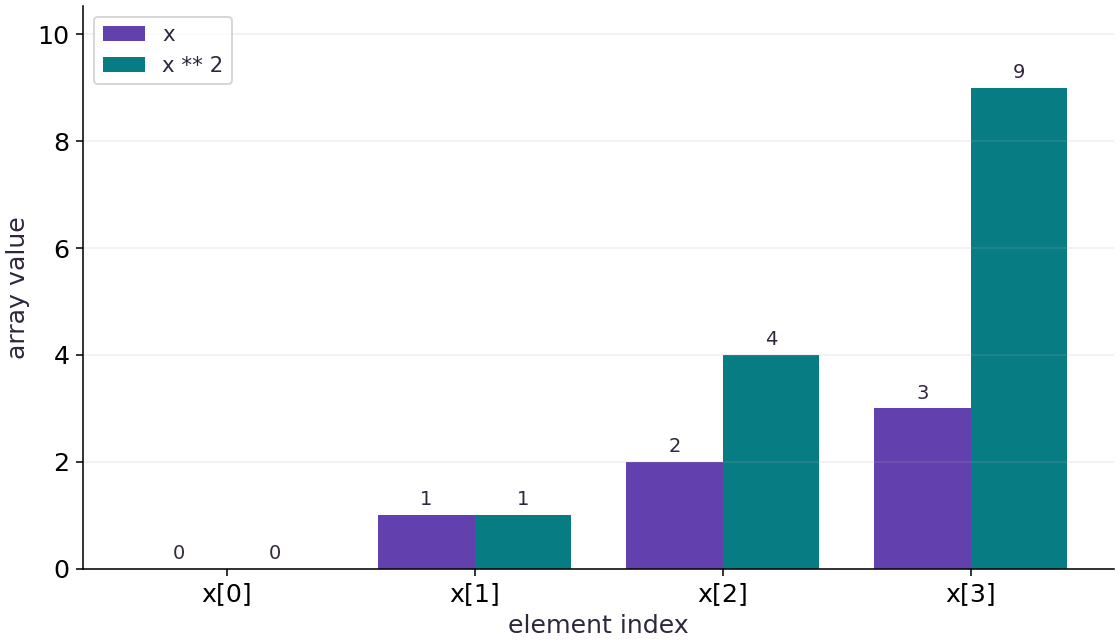

In [6]:
# Render the figure from the data computed above. Change the data experiment and rerun.
import matplotlib.pyplot as plt
plt.rcParams.update({'font.family': 'DejaVu Sans', 'font.size': 13, 'axes.labelcolor': '#30273e', 'text.color': '#30273e'})
def draw_panel(ax, data):
    import numpy as np
    palette = ['#6240ad', '#087c83', '#bc532c', '#405d9d']
    kind = data['kind']
    if kind in ('heatmap', 'field'):
        a = np.asarray(data['values'], dtype=float)
        assert a.ndim == 2 and np.isfinite(a).all()
        kw = {'cmap': 'PuOr' if data.get('diverging') else 'Purples', 'aspect': 'auto'}
        if kind == 'field':
            kw.update(extent=data['extent'], origin='lower', vmin=0, vmax=1)
        elif data.get('diverging'):
            limit = max(float(np.abs(a).max()), 1e-10)
            kw.update(vmin=-limit, vmax=limit)
        if data.get('scale') == 'probability' or data['unit'] in ('attention weight', 'next-token probability', 'masked-token probability'):
            kw.update(vmin=0, vmax=1)
        categorical = data.get('scale') == 'categorical' or any(name in data['unit'] for name in ('device ID','program ID'))
        if categorical:
            from matplotlib.colors import ListedColormap, BoundaryNorm
            from matplotlib import colormaps
            ids=np.unique(a).astype(int)
            boundaries=np.r_[ids[0]-.5,(ids[:-1]+ids[1:])/2,ids[-1]+.5]
            kw.update(cmap=ListedColormap([colormaps['tab20'](i) for i in range(len(ids))]), norm=BoundaryNorm(boundaries,len(ids)))
        im = ax.imshow(a, **kw)
        ax.figure.colorbar(im, ax=ax, shrink=0.8, label=data['unit'], **({'ticks':ids} if categorical else {}))
        if kind == 'heatmap':
            if a.size <= 32:
                mid = (float(a.min()) + float(a.max())) / 2
                for (i, j), value in np.ndenumerate(a):
                    rgb=im.cmap(im.norm(value))[:3]
                    luminance=sum(c*w for c,w in zip(rgb,[0.2126,0.7152,0.0722]))
                    ax.text(j, i, f'{value:.3g}', ha='center', va='center', fontsize=11,
                            color='white' if luminance < 0.5 else '#20202c')
            ax.set_xticks(range(a.shape[1]), data.get('columns', [str(i) for i in range(a.shape[1])]))
            ax.set_yticks(range(a.shape[0]), data.get('rows', [str(i) for i in range(a.shape[0])]))
            if a.shape[1] > 5: ax.tick_params(axis='x', labelsize=11)
        else:
            pts = np.asarray(data['points']); labels = np.asarray(data['labels'])
            for label, marker in [(0, 'o'), (1, '^')]:
                selected = pts[labels == label]
                ax.scatter(selected[:, 0], selected[:, 1], label=f'observed label {label}', marker=marker,
                           s=38, facecolors='white' if label == 0 else '#f4b547', edgecolors='#272238', linewidths=1)
            ax.legend(loc='upper left', fontsize=10)
    elif kind in ('line', 'bar'):
        series = data['series']
        x = np.asarray(data.get('x', list(range(len(data.get('labels', []))))))
        assert len(x) and np.isfinite(x).all()
        for i, s in enumerate(series):
            y = np.asarray(s['y'], dtype=float)
            assert y.shape == x.shape and np.isfinite(y).all(), s['label']
            if data.get('yscale') == 'log': assert (y > 0).all()
            if kind == 'line':
                ax.plot(x, y, color=palette[i % len(palette)], label=s['label'], linewidth=2.3,
                        linestyle=['-', '--', '-.', ':'][i % 4], marker='o' if len(x) <= 25 else None, markersize=3)
            else:
                width = 0.78 / len(series)
                bars = ax.bar(x + (i - (len(series)-1)/2)*width, y, width, label=s['label'], color=palette[i % len(palette)])
                if len(x)*len(series) <= 12: ax.bar_label(bars, fmt='%.3g', fontsize=10, padding=3)
        if kind == 'bar':
            ax.set_xticks(x, data['labels'])
            ax.margins(y=0.17)
            if any(len(t) > 13 for t in data['labels']): ax.tick_params(axis='x', labelrotation=15, labelsize=11)
        if data.get('xscale'): ax.set_xscale(data['xscale'])
        if data.get('yscale'): ax.set_yscale(data['yscale'], **({'linthresh':data.get('linthresh',2)} if data['yscale']=='symlog' else {}))
        for marker in data.get('markers',[]):
            ax.scatter([marker['x']],[marker['y']],color='#bc532c',s=45,zorder=5)
            ax.annotate(marker['label'],(marker['x'],marker['y']),xytext=(-85,12),textcoords='offset points',fontsize=10)
        for boundary in data.get('boundaries', []): ax.axvline(boundary, color='#716e7b', linestyle=':', linewidth=1)
        ax.grid(axis='y', alpha=0.2)
        ax.legend(fontsize=11, loc='best')
    elif kind == 'vectors':
        for i, arrow in enumerate(data['arrows']):
            start = np.asarray(arrow['start']); end = np.asarray(arrow['end'])
            ax.annotate('', xy=end, xytext=start, arrowprops={'arrowstyle':'->','color':palette[i], 'lw':2.8})
            mid=(start+end)/2
            ax.annotate(arrow['label'], mid, xytext=(7,7), textcoords='offset points', color=palette[i])
        ax.set(xlim=(-0.7,4.5),ylim=(-0.7,5),xlabel='first coordinate',ylabel='second coordinate')
        ax.set_aspect('equal'); ax.grid(alpha=0.2)
    elif kind == 'flow':
        from matplotlib.patches import FancyBboxPatch
        nodes=data['nodes']; ax.set(xlim=(0,1),ylim=(0,len(nodes))); ax.axis('off')
        if data.get('layout') == 'merge':
            import textwrap
            for i,label in enumerate(nodes[:3]):
                x=0.02+i*0.33
                ax.add_patch(FancyBboxPatch((x,3.7),0.29,1.0,boxstyle='round,pad=0.015',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(x+0.145,4.2,textwrap.fill(label,20),ha='center',va='center',fontsize=11)
                ax.annotate('',(0.5,2.8),(x+0.145,3.67),arrowprops={'arrowstyle':'->','color':'#6240ad'})
            for y,label in [(2.4,nodes[3]),(0.9,nodes[4])]:
                ax.add_patch(FancyBboxPatch((0.08,y-0.35),0.84,0.7,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
            ax.annotate('',(0.5,1.3),(0.5,2.0),arrowprops={'arrowstyle':'->','color':'#6240ad'})
        else:
            for i, label in enumerate(nodes):
                y=len(nodes)-i-0.5
                ax.add_patch(FancyBboxPatch((0.08,y-0.3),0.84,0.6,boxstyle='round,pad=0.025',facecolor='#f0eafa',edgecolor='#6240ad'))
                ax.text(0.5,y,label,ha='center',va='center',fontsize=12)
                if i<len(nodes)-1: ax.annotate('',(0.5,y-0.67),(0.5,y-0.32),arrowprops={'arrowstyle':'->','color':'#6240ad'})
    else: raise ValueError(f'Unknown figure kind: {kind}')
    if data.get('xlabel'): ax.set_xlabel(data['xlabel'])
    if data.get('ylabel'): ax.set_ylabel(data['ylabel'])
    if data.get('title'): ax.set_title(data['title'], loc='left', fontsize=12, pad=12)
    for spine in ('top','right'): ax.spines[spine].set_visible(False)


def draw_mechanism(ax, diagram):
    """Draw a source-authored conceptual/analytic mechanism, never measured data."""
    import numpy as np
    from matplotlib.patches import FancyBboxPatch, Rectangle, Circle, Ellipse
    panel = diagram['panel']
    kind = panel['kind']
    colors = {'data':('#eef3ff','#3559a8'), 'state':('#f0eafa','#6240ad'),
              'fixed':('#f1f3f5','#536273'), 'result':('#e5f4ee','#17735c'),
              'warning':('#fff0e6','#a64d20')}
    if kind == 'graph':
        ax.set(xlim=(0,panel.get('width',10)),ylim=(panel.get('height',8),0))
        ax.axis('off')
        nodes={node['id']:node for node in panel['nodes']}
        for edge in panel['edges']:
            a,b=nodes[edge['from']],nodes[edge['to']]
            side_a=edge.get('exit','bottom'); side_b=edge.get('enter','top')
            def port(node,side):
                x,y=node['x'],node['y']; w,h=node.get('w',3),node.get('h',.8)
                return {'top':(x,y-h/2),'bottom':(x,y+h/2),'left':(x-w/2,y),'right':(x+w/2,y)}[side]
            start,end=port(a,side_a),port(b,side_b)
            ax.annotate('',xy=end,xytext=start,arrowprops={'arrowstyle':'-|>','color':'#536273','lw':1.7,'connectionstyle':edge.get('curve','arc3,rad=0')},zorder=1)
            if edge.get('label'):
                tx,ty=edge.get('labelAt',((start[0]+end[0])/2,(start[1]+end[1])/2))
                ax.text(tx,ty,edge['label'],ha='center',va='center',fontsize=10,color='#394658',bbox={'facecolor':'white','edgecolor':'none','pad':2},zorder=4)
        for node in panel['nodes']:
            fill,stroke=colors[node.get('tone','data')]
            x,y=node['x'],node['y'];w,h=node.get('w',3),node.get('h',.8)
            ax.add_patch(FancyBboxPatch((x-w/2,y-h/2),w,h,boxstyle='round,pad=0.02,rounding_size=0.07',facecolor=fill,edgecolor=stroke,lw=1.5,zorder=2))
            ax.text(x,y,node['label'],ha='center',va='center',fontsize=node.get('fontSize',12),color='#172334',zorder=3)
    elif kind == 'table':
        ax.axis('off')
        table=ax.table(cellText=panel['rows'],colLabels=panel['headers'],cellLoc='center',loc='center',colWidths=panel.get('widths'))
        table.auto_set_font_size(False);table.set_fontsize(12);table.scale(1,2.7)
        for (row,col),cell in table.get_celld().items():
            cell.set_edgecolor('#ccd3df')
            cell.set_facecolor('#e9e4f5' if row==0 else ('#f4f7fb' if row%2 else '#ffffff'))
            cell.set_text_props(color='#172334',weight='bold' if row==0 else 'normal')
    elif kind == 'clipping':
        ax.add_patch(Circle((0,0),2.5,fill=False,edgecolor='#17735c',linestyle='--',lw=1.8))
        ax.add_patch(Rectangle((-2.5,-2.5),5,5,fill=False,edgecolor='#a64d20',linestyle=':',lw=1.8))
        for end,color,label,offset in [((3,4),'#3559a8','Original (3, 4)',(8,5)),((1.5,2),'#17735c','Norm clip (1.5, 2)',(-126,-16)),((2.5,2.5),'#a64d20','Coordinate clip (2.5, 2.5)',(8,-2))]:
            ax.annotate('',xy=end,xytext=(0,0),arrowprops={'arrowstyle':'-|>','color':color,'lw':2.6})
            ax.annotate(label,end,xytext=offset,textcoords='offset points',color=color,fontsize=11)
        ax.set(xlim=(-3,5.8),ylim=(-3,4.8),xlabel='gradient coordinate 1',ylabel='gradient coordinate 2')
        ax.set_aspect('equal');ax.grid(alpha=.15)
    elif kind == 'patches':
        ax.set(xlim=(-.1,4.1),ylim=(4.1,-.1));ax.set_aspect('equal');ax.axis('off')
        for i in range(4):
            x,y=(i%2)*2,(i//2)*2
            visible=i in [0,3]
            ax.add_patch(Rectangle((x,y),2,2,facecolor='#e5f4ee' if visible else '#fff0e6',edgecolor='#17735c' if visible else '#a64d20',hatch=None if visible else '///',lw=2))
            ax.text(x+1,y+1,f'Patch {i}\n'+('visible input' if visible else 'hidden target'),ha='center',va='center',fontsize=14,bbox={'facecolor':'white','edgecolor':'none','alpha':.94,'pad':5})
        for a in [1,3]:
            ax.axhline(a,color='#172334',alpha=.25,lw=.7);ax.axvline(a,color='#172334',alpha=.25,lw=.7)
    elif kind == 'receptive-field':
        ax.set(xlim=(-.15,5.15),ylim=(5.15,-.15));ax.set_aspect('equal');ax.axis('off')
        for row in range(5):
            for col in range(5):
                selected=1<=row<=3 and 1<=col<=3
                ax.add_patch(Rectangle((col,row),1,1,facecolor='#e9e4f5' if selected else '#f4f7fb',edgecolor='#a6afc1',lw=1))
                ax.text(col+.5,row+.5,f'{row},{col}',ha='center',va='center',fontsize=12)
        ax.add_patch(Rectangle((1,1),3,3,fill=False,edgecolor='#6240ad',lw=3))
        ax.set_title('One 3 × 3 receptive field inside a 5 × 5 input',fontsize=13,pad=12)
    elif kind == 'covariance':
        for covariance,color,label in [(np.array([[1,.8],[.8,1]]),'#6240ad','Correlated covariance'),(np.eye(2),'#17735c','Same marginals, zero covariance')]:
            eig,vec=np.linalg.eigh(covariance);order=np.argsort(eig)[::-1];eig=eig[order];vec=vec[:,order]
            angle=np.degrees(np.arctan2(vec[1,0],vec[0,0]))
            ax.add_patch(Ellipse((0,0),2*np.sqrt(eig[0]),2*np.sqrt(eig[1]),angle=angle,fill=False,lw=2.5,edgecolor=color,label=label))
        ax.set(xlim=(-1.8,1.8),ylim=(-1.8,1.8),xlabel='first variable',ylabel='second variable')
        ax.set_aspect('equal');ax.grid(alpha=.2);ax.legend(loc='upper center',bbox_to_anchor=(.5,-.14),fontsize=10)
    elif kind == 'timeline':
        ax.set(xlim=(0,10),ylim=(-.7,2.7),yticks=[0,1,2],yticklabels=['Host','Device','Measurement'])
        for start,length,y,label,color in [(0,1,0,'dispatch','#3559a8'),(1,6,1,'device work','#6240ad'),(1,6,0,'wait for result','#a64d20'),(0,7,2,'completed-result interval','#17735c')]:
            ax.barh(y,length,left=start,height=.45,color=color,alpha=.18)
            ax.text(start+length/2,y,label,ha='center',va='center',fontsize=11)
        ax.axvline(7,color='#536273',linestyle='--');ax.text(7.1,.5,'result ready',fontsize=11)
        ax.set_xlabel('conceptual order; lengths are not measured durations')
        ax.invert_yaxis()
    else:
        raise ValueError(f'Unknown mechanism kind: {kind}')

panels = visual_data.get('panels', [visual_data])
fig, axes = plt.subplots(len(panels), 1, figsize=(8, 4.6 * len(panels)), squeeze=False, layout='constrained')
for ax, panel in zip(axes[:, 0], panels):
    draw_panel(ax, panel)
plt.show()

### Read the figure

Each index shows the initialized JAX array element alongside its elementwise square on the active device.

### Connect it to the computation

Running this check confirms that JAX, NumPy, and Matplotlib execute deterministically in your local environment.

## Your exercise

Edit the starter as shown in Step $6$: change the array length from $4$ to $6$ and the expected sum from $6$ to $15$. Save, rerun, and keep my-first-run.txt plus a note explaining why the result changed.

### How to write this exercise — Step-by-step recipe & starter scaffold

**Key functions & syntax to use:**
- `x.sum(axis=...) / x.mean(axis=..., keepdims=...)` — Reduces values along the named `axis` (the axis you name is collapsed unless `keepdims=True`).

**Step-by-step implementation plan:**
1. Print the observed values to compare against the expected result.
2. Assert invariant `float(x.sum()) == 15.0` holds

**Starter code scaffold (fill in the TODOs):**

```python
# Exercise solution: Edit the starter as shown in Step 6: change the array length from 4 to...
x = jax.numpy.arange(...)  # TODO: compute x
# Print the observed values to compare against the expected result.
print("Changed experiment sum:", float(x.sum()))
# Assert invariant `float(x.sum()) == 15.0` holds
assert float(x.sum())  # TODO: complete assertion check
```

In [7]:
# Write your attempt here (uncomment and fill in the TODOs below):
# Exercise solution: Edit the starter as shown in Step 6: change the array length from 4 to...
# x = jax.numpy.arange(...)  # TODO: compute x
# Print the observed values to compare against the expected result.
# print("Changed experiment sum:", float(x.sum()))
# Assert invariant `float(x.sum()) == 15.0` holds
# assert float(x.sum())  # TODO: complete assertion check

## Reference solution

Try your own implementation first.

In [8]:
# Exercise solution: Edit the starter as shown in Step 6: change the array length from 4 to...
x = jax.numpy.arange(6, dtype=jax.numpy.float32)
# Print the observed values to compare against the expected result.
print("Changed experiment sum:", float(x.sum()))
# Assert invariant `float(x.sum()) == 15.0` holds
assert float(x.sum()) == 15.0

Changed experiment sum: 15.0


## Checkpoint

Which evidence lets another learner reproduce your environment?

1. A screenshot of the final number only
2. Python/package versions, device information, and the script
3. The name of your editor

## Diagnose

Use the troubleshooting section to identify the failing step. Keep the command and final error line, then verify the fix by repeating that step. Successful package installation, successful imports, and a correct numerical result are three separate checks.

## Evidence

Keep first_experiment.py, my-first-run.txt with package/device output, the environment interpreter path, and a note deriving the change from a sum of 6 to 15. Record a setup error and its repair if you encountered one.

## Carry forward

- Terminal commands run from a working folder; Python statements live in the .py file.
- The environment interpreter determines which installed packages the program uses.
- Expected values let you check the numerical result after a deliberate edit.
- Keep your code and results outside .venv so the environment can be recreated.

## Primary references

- [Python downloads: choose Python 3.14 for your operating system](https://www.python.org/downloads/)
- [Python: creating and using virtual environments](https://docs.python.org/3.14/library/venv.html)
- [JAX: installation and supported platforms](https://docs.jax.dev/en/latest/installation.html)